## Leaf Species Classification with Logistic Regression

**Module:** Statistical Data Science (COMM071)


**Short description:**
This notebook analyses leaf measurements (length and width) from two tree species and builds logistic regression classifiers to predict species membership. I compare a baseline linear model with polynomial extensions, evaluate them on held-out test data and visualise decision boundaries and performance metrics.

## Task 1

**Data Cleaning**

In [215]:
# Load the leaf dataset into R
# I store the data in a variable named data_6908119
# Which corresponds to my student ID for clarity

data_6908119<-read.csv("leaf_data.csv")

In [216]:
# Before working with the dataset, I am checking the current column names
colnames(data_6908119)

[1] "Leaf.length" "Leaf.width"  "Species"

In [217]:
# Renaming the columns so they are easier to work with
colnames(data_6908119)<-c("LeafLength","LeafWidth","Species")

# Display current columns
colnames(data_6908119)

[1] "LeafLength" "LeafWidth"  "Species"

In [218]:
# Make sure the data types are correct for analysis
# Covert leaf measurements to numeric in case they were read as text
data_6908119$LeafLength<-as.numeric(as.character(data_6908119$LeafLength))
data_6908119$LeafWidth<-as.numeric(as.character(data_6908119$LeafWidth))

# Convert Species to a factor because it's a categorical variable
data_6908119$Species<-factor(data_6908119$Species)

In [219]:
# Remove any rows with missing values so our analysis won't run into errors
data_6908119<-na.omit(data_6908119)

# Let's see how many rows we have left after removing NAs
nrow(data_6908119)

[1] 411

In [220]:
# Take a quick look at the dataset
# Show the first few rows
head(data_6908119)

,LeafLength,LeafWidth,Species
,<dbl>,<dbl>,<fct>
1,7.056281,1.785854,Species B
2,3.221461,1.291666,Species B
3,4.301642,3.762306,Species B
4,1.792758,2.645035,Species A
5,4.869164,4.764559,Species A
6,4.460749,3.180579,Species B


In [221]:
# Check structure of dataset make sure the columns are in the right format
str(data_6908119)

'data.frame':	411 obs. of  3 variables:
 $ LeafLength: num  7.06 3.22 4.3 1.79 4.87 ...
 $ LeafWidth : num  1.79 1.29 3.76 2.65 4.76 ...
 $ Species   : Factor w/ 2 levels "Species A","Species B": 2 2 2 1 1 2 1 1 1 2 ...


In [222]:
# Look at the basic summary of the dataset
# This helps me understand the range and typical values for each column
summary(data_6908119)

   LeafLength       LeafWidth            Species   
 Min.   :0.4203   Min.   :-0.6694   Species A:183  
 1st Qu.:3.6336   1st Qu.: 1.8954   Species B:228  
 Median :4.8685   Median : 2.7925                  
 Mean   :4.9077   Mean   : 2.8513                  
 3rd Qu.:6.1131   3rd Qu.: 3.8345                  
 Max.   :9.4200   Max.   : 6.1614                  

**Data Cleaning Notes:**
Renamed columns for clarity, converted leaf measurements to numeric, converted species to a factor and cleared out any NA rows to avoid issues during modelling.

**Load Packages**

In [223]:
library(caTools)
library(caret)
library(ggplot2)
library(dplyr)
library(pROC)
library(patchwork)

**Exploratory visualisation**

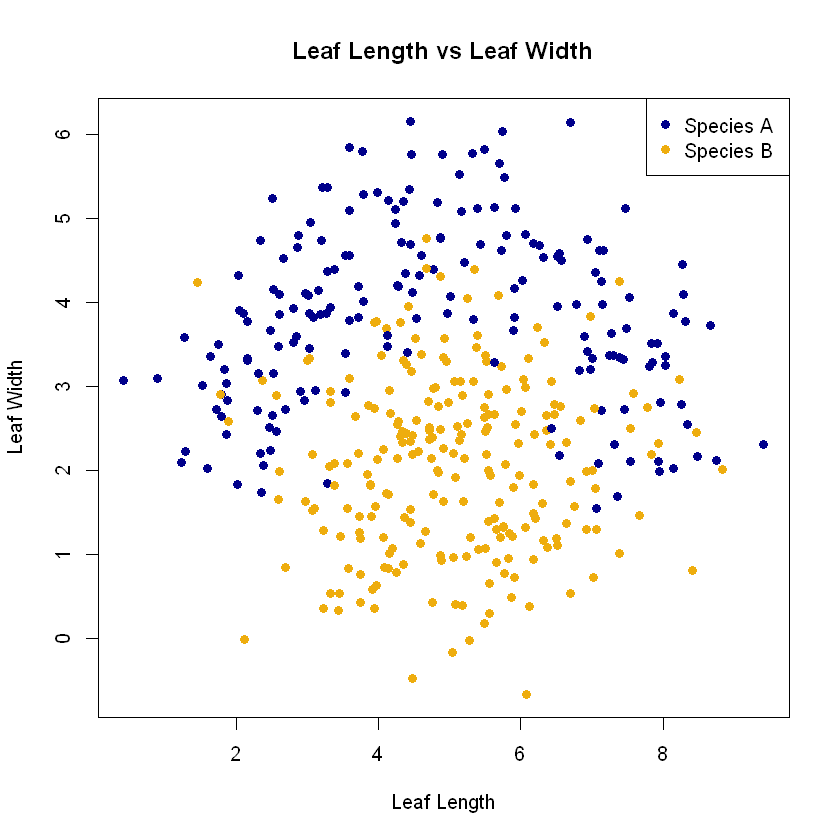

In [224]:
# A basic scatter plot to see how leaf length and leaf width are related
# Color points by species to see if they separate naturally

cols_custom<-c("darkblue","darkgoldenrod2")

plot(data_6908119$LeafLength, data_6908119$LeafWidth,
    col=cols_custom[data_6908119$Species],
    pch=19,
    xlab="Leaf Length",
    ylab="Leaf Width",
    main="Leaf Length vs Leaf Width")

legend("topright",
      legend=levels(data_6908119$Species),
      col=cols_custom,
      pch=19)

**Exploratory visualisation Notes:** The scatter plot shows that leaf length and width mostly separate the two species, though a few points lie near the boundary and might be outliers or overlapping measurements.

**Train/ Test split**

In [225]:
# Separating the dataset into training and testing parts
# I went with a 70/30 split so the training set stays large

set.seed(123) # so I get the same split each time

split_flag<-sample.split(data_6908119$Species, SplitRatio=0.7)
train_chunk<-subset(data_6908119, split_flag==TRUE)
test_chunk<-subset(data_6908119, split_flag==FALSE)

# Check how many rows are in each set
nrow(train_chunk)
nrow(test_chunk)

[1] 288

[1] 123

In [226]:
# Checking the class proportions in each set
prop.table(table(train_chunk$Species))
prop.table(table(test_chunk$Species))


Species A Species B 
0.4444444 0.5555556 


Species A Species B 
0.4471545 0.5528455 

**Data Split Notes:** I just did a 70/30 split for the data so the model gets enough to train. Added a seed so it won't keep changing every time I run it. After splitting, I checked the row numbers and the species mix. Both sides look almost the same, so I think the split is okay.

**Baseline Logistic Regression Model**

In [227]:
# Building the basic logit model
simple_logit<-glm(
   Species~LeafLength + LeafWidth,
   data=train_chunk,
   family="binomial"
)

summary(simple_logit)


Call:
glm(formula = Species ~ LeafLength + LeafWidth, family = "binomial", 
    data = train_chunk)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  3.80739    0.64112   5.939 2.87e-09 ***
LeafLength   0.08726    0.08004   1.090    0.276    
LeafWidth   -1.36289    0.16371  -8.325  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 395.69  on 287  degrees of freedom
Residual deviance: 269.03  on 285  degrees of freedom
AIC: 275.03

Number of Fisher Scoring iterations: 5


**Baseline Logistic Regression Notes:** I made a simple logistic model using leaf length and leaf width. I just wanted to see how these two measurements help in telling the species

**Polynomial Logistic Regression Models**

In [228]:
# Creating polynomial logistic regression models with increasing flexibility

# Model with squared terms (second-order)
model_poly2 <- glm(
  Species ~ poly(LeafLength, 2) + poly(LeafWidth, 2),
  family = "binomial",
  data = train_chunk
)

# Model including cubic terms (third-order)
model_poly3 <- glm(
  Species ~ poly(LeafLength, 3) + poly(LeafWidth, 3),
  family = "binomial",
  data = train_chunk
)

# Model including fourth-order terms
model_poly4 <- glm(
  Species ~ poly(LeafLength, 4) + poly(LeafWidth, 4),
  family = "binomial",
  data = train_chunk
)

# Model including fifth-order terms
model_poly5 <- glm(
  Species ~ poly(LeafLength, 5) + poly(LeafWidth, 5),
  family = "binomial",
  data = train_chunk
)


Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"


In [229]:
#summary(model_poly2)
#summary(model_poly3)
#summary(model_poly4)
#summary(model_poly5)

In [230]:
# ----- Second-order model -----
cat("=== Model: Polynomial (Degree 2) ===\n")
cat("Coefficients:\n")
print(coef(model_poly2))
cat("\nAIC:", AIC(model_poly2), "\n")
cat("Deviance:", model_poly2$deviance, "\n\n")

# ----- Third-order model -----
cat("=== Model: Polynomial (Degree 3) ===\n")
cat("Coefficients:\n")
print(coef(model_poly3))
cat("\nAIC:", AIC(model_poly3), "\n")
cat("Deviance:", model_poly3$deviance, "\n\n")

# ----- Fourth-order model -----
cat("=== Model: Polynomial (Degree 4) ===\n")
cat("Coefficients:\n")
print(coef(model_poly4))
cat("\nAIC:", AIC(model_poly4), "\n")
cat("Deviance:", model_poly4$deviance, "\n\n")

# ----- Fifth-order model -----
cat("=== Model: Polynomial (Degree 5) ===\n")
cat("Coefficients:\n")
print(coef(model_poly5))
cat("\nAIC:", AIC(model_poly5), "\n")
cat("Deviance:", model_poly5$deviance, "\n\n")


=== Model: Polynomial (Degree 2) ===
Coefficients:
         (Intercept) poly(LeafLength, 2)1 poly(LeafLength, 2)2 
           0.2563839            4.7586906          -32.6731074 
 poly(LeafWidth, 2)1  poly(LeafWidth, 2)2 
         -40.8627114          -13.6611193 

AIC: 181.9974 
Deviance: 171.9974 

=== Model: Polynomial (Degree 3) ===
Coefficients:
         (Intercept) poly(LeafLength, 3)1 poly(LeafLength, 3)2 
           0.1522977            6.1851272          -32.5009479 
poly(LeafLength, 3)3  poly(LeafWidth, 3)1  poly(LeafWidth, 3)2 
           4.1952517          -49.3808177          -15.6296633 
 poly(LeafWidth, 3)3 
         -10.5336502 

AIC: 184.2996 
Deviance: 170.2996 

=== Model: Polynomial (Degree 4) ===
Coefficients:
         (Intercept) poly(LeafLength, 4)1 poly(LeafLength, 4)2 
           0.8970395            4.4529931          -29.7692754 
poly(LeafLength, 4)3 poly(LeafLength, 4)4  poly(LeafWidth, 4)1 
           1.0552091            9.5727958          -59.6138372 
 po

**Poly logistic regression Notes:** After checking the outputs for all the models, I noticed that the lower-degree ones gave smooth and sensible curves. When the degree increased, the models started bending more sharply around the data, which made them look like they were beginning to overfit.

## Task 2

**Predict on test data and evaluate model performance**

In [231]:
# Linear model predictions
pred_lin_prob <- predict(
  object = simple_logit,
  newdata = test_chunk,
  type = "response"
)

pred_lin_class<- factor(
  ifelse(pred_lin_prob > 0.5,
         levels(train_chunk$Species)[2],
         levels(train_chunk$Species)[1]),
  levels = levels(train_chunk$Species)
)

# Confusion table for the linear model
cm_lin <- confusionMatrix(pred_lin_class, test_chunk$Species)

In [232]:
# Quadratic model predictions
prob_d2<-predict(
    object=model_poly2,
    newdata = test_chunk,
    type = "response"
)

class_d2 <- factor(
  ifelse(prob_d2 >= 0.5,
         levels(train_chunk$Species)[2],
         levels(train_chunk$Species)[1]),
  levels = levels(train_chunk$Species)
)

# Confusion table
cm_d2 <- confusionMatrix(class_d2, test_chunk$Species)

In [233]:
# Cubic model predictions
prob_d3<-predict(
  object = model_poly3,
  newdata = test_chunk,
  type   = "response"
)

class_d3<-factor(
  ifelse(prob_d3 >= 0.5,
         levels(train_chunk$Species)[2],
         levels(train_chunk$Species)[1]),
  levels = levels(train_chunk$Species)
)

# Confusion table
cm_d3 <- confusionMatrix(class_d3, test_chunk$Species)

In [234]:
# Quartic model predictions
prob_d4 <- predict(
    object=model_poly4,
    newdata = test_chunk,
    type = "response"
)

class_d4 <- factor(
  ifelse(prob_d4 >= 0.5,
         levels(train_chunk$Species)[2],
         levels(train_chunk$Species)[1]),
  levels = levels(train_chunk$Species)
)

# Confusion table
cm_d4 <- confusionMatrix(class_d4, test_chunk$Species)

In [235]:
# Quintic model predictions
prob_d5 <- predict(
    object=model_poly5,
    newdata = test_chunk,
    type = "response"
)

class_d5<- factor(
  ifelse(prob_d5>= 0.5,
         levels(train_chunk$Species)[2],
         levels(train_chunk$Species)[1]),
  levels = levels(train_chunk$Species)
)

# Confusion table
cm_d5 <- confusionMatrix(class_d5, test_chunk$Species)

**Model Performance Notes:** Here I use 4 degrees. The baseline seems okay but as I moved to degrees 2,3,4 the accuracy went up. 4 looked best but degree 5 was not good it was overfitting.

**Extract key performance metrics from the confusion matrices**

In [236]:
# Linear model metrics

acc_lin   <- cm_lin$overall["Accuracy"]
kappa_lin <- cm_lin$overall["Kappa"]
sens_lin  <- cm_lin$byClass["Sensitivity"]
spec_lin  <- cm_lin$byClass["Specificity"]

In [237]:
# Quadratic model metrics

acc_deg2   <- cm_d2$overall["Accuracy"]
kappa_deg2 <- cm_d2$overall["Kappa"]
sens_deg2  <- cm_d2$byClass["Sensitivity"]
spec_deg2  <- cm_d2$byClass["Specificity"]

In [238]:
# Cubic model metrics

acc_deg3   <- cm_d3$overall["Accuracy"]
kappa_deg3 <- cm_d3$overall["Kappa"]
sens_deg3  <- cm_d3$byClass["Sensitivity"]
spec_deg3  <- cm_d3$byClass["Specificity"]

In [239]:
# Quartic model metrics

acc_deg4   <- cm_d4$overall["Accuracy"]
kappa_deg4 <- cm_d4$overall["Kappa"]
sens_deg4  <- cm_d4$byClass["Sensitivity"]
spec_deg4  <- cm_d4$byClass["Specificity"]

In [240]:
# Quintic model metrics

acc_deg5   <- cm_d5$overall["Accuracy"]
kappa_deg5 <- cm_d5$overall["Kappa"]
sens_deg5  <- cm_d5$byClass["Sensitivity"]
spec_deg5  <- cm_d5$byClass["Specificity"]

In [241]:
# Combine everything into one table

metrics_df <- data.frame(
  Model = c("Linear", "Poly2", "Poly3", "Poly4", "Poly5"),
  Accuracy = c(acc_lin, acc_deg2, acc_deg3, acc_deg4, acc_deg5),
  Kappa = c(kappa_lin, kappa_deg2, kappa_deg3, kappa_deg4, kappa_deg5),
  Sensitivity = c(sens_lin, sens_deg2, sens_deg3, sens_deg4, sens_deg5),
  Specificity = c(spec_lin, spec_deg2, spec_deg3, spec_deg4, spec_deg5)
)

cat("=== Accuracy for Each Model ===\n")
cat("Linear:", round(acc_lin,4), "\n")
cat("Poly2 :", round(acc_deg2,4), "\n")
cat("Poly3 :", round(acc_deg3,4), "\n")
cat("Poly4 :", round(acc_deg4,4), "\n")
cat("Poly5 :", round(acc_deg5,4), "\n\n")

# Display the comparison table
metrics_df

=== Accuracy for Each Model ===
Linear: 0.8618 
Poly2 : 0.8943 
Poly3 : 0.9024 
Poly4 : 0.9106 
Poly5 : 0.878 



Model,Accuracy,Kappa,Sensitivity,Specificity
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Linear,0.8617886,0.7189894,0.8181818,0.8970588
Poly2,0.8943089,0.7866008,0.8909091,0.8970588
Poly3,0.9024390,0.8026738,0.8909091,0.9117647
Poly4,0.9105691,0.8188027,0.8909091,0.9264706
Poly5,0.8780488,0.7520495,0.8363636,0.9117647


**Selected Metrics Notes:** I extracted the key metrics - Accuracy, Kappa, Sensitivity and Specificity for all the models so I could compare them side-by-side. Looking at these values together made it easier to judge which model improved the predictions and which ones added complexity without giving much benefit.

**Model Evaluation and Discussion**

In Task 1 I built five models: one linear logistic model and four polynomial models with degrees 2,3,4 and 5. To check how well they really worked, I did not test them on the training data. Instead, I used the testing dataset, A part of the data that was kept separate. For each model, I made predictions on this test data and used a confusion matrix to get four main measures: accuracy, sensitivity, specificity and kappa. Accuracy shows the overall share of correct predictions. Sensitivity tells me how well the model finds Species A and specificity tells me how well it recognises Species B. Kappa shows how much the model agrees with the real labels beyond just guessing.

The linear model reached about 86% accuracy. The polynomial models did better at first: degree 2 and 3 were around 89–90% and degree 4 was the best about 91%, with good sensitivity and specificity for both species. The degree 5 model then dropped around 88% which suggests it was starting to overfit. So from these test results, it's clear that a bit of extra complexity helps the model, but pushing it too far actually makes the performance drop.

## Task 3

**discussion - Model Complexity, Performance and Decision Boundaries**

In this coursework, I compared five logistic regression models to see how their complexity affects both their performance and the shape of the decision boundary. I started with a simple linear model and then added polynomial terms of degree 2, 3, 4 and 5. The idea was to see whether extra flexibility helps the model to understand the curve separation between the two species or whether it becomes too complex and starts to overfit.

The linear model was the most straightforward. It draws a single straight line to separate the two species based on leaf length and width. The scatter plot I made earlier already showed that a straight line can’t fully separate the two species, so I expected this model to do only a basic job. Its accuracy on the test set was around 86%, which shows that the two measurements do give useful information, but the boundary is too simple for the patterns in the data. The decision boundary plot confirmed this the line cut through the middle but missed some of the curved structure around the cluster.

When I moved to the polynomial models, the performance started improving right away. The degree 2 model introduced the first curved boundary. This allowed the model to bend its line around the groups in a more realistic way. The accuracy went up to about 89%, and sensitivity and specificity both increased, meaning the model handled both species more fairly. The boundary plot also showed a visible improvement, as the curve followed the main shape of the data more closely.

The degree 3 and degree 4 models continued this trend. The cubic model reached around 90%, and the quartic model gave the best performance overall at about 91% accuracy. At this point, the decision boundary looked smooth and well-fitted to the distribution of the points. The ROC curve also showed that the degree-4 model stayed above the others for most of the range, which means it separated the classes better at different probability thresholds. From both the metrics and the plots, degree 4 appeared to strike the best balance between flexibility and stability.

The degree 5 model was different. Even Though it had the most flexibility, the performance dropped to around 88%, which is lower than some of the simpler models. The coefficients also became extremely large, which is usually a warning sign that the model is fitting noise in the training data. The decision boundary looked over wiggly and did not match the overall trend of the scatter plot anymore. This is a classic example of overfitting where the model becomes too sensitive to small variations and loses its ability to generalise to new data.

Overall, the results show a clear pattern. Increasing model complexity helps only up to a certain point. The linear model underfits because it is too simple. Degrees 2, 3 and 4 gradually improve the fit by capturing the curved shape in the data. Degree 4 gives the strongest performance and the cleanest decision boundary. Degree 5 becomes too flexible and ends up performing worse. From this, I would choose the quartic model as the best balance between accuracy, stability and meaningful decision boundaries.

## Task 4

**Model Fit and Performance Visualisation**

In [257]:
# Decision Boundary for all models

# Create grid for plotting
len_seq <- seq(min(data_6908119$LeafLength), max(data_6908119$LeafLength), length.out = 200)
wid_seq <- seq(min(data_6908119$LeafWidth),  max(data_6908119$LeafWidth),  length.out = 200)

grid_df <- expand.grid(
  LeafLength = len_seq,
  LeafWidth  = wid_seq
)

# Predict on the grid for all models
grid_df$pred_lin <- predict(simple_logit, newdata = grid_df, type = "response")
grid_df$pred_d2  <- predict(model_poly2,  newdata = grid_df, type = "response")
grid_df$pred_d3  <- predict(model_poly3,  newdata = grid_df, type = "response")
grid_df$pred_d4  <- predict(model_poly4,  newdata = grid_df, type = "response")
grid_df$pred_d5  <- predict(model_poly5,  newdata = grid_df, type = "response")

# Colours for species
species_cols <- c("Species A" = "#9A031E", "Species B" = "#228B22")

# Function to draw decision boundaries
plot_decision <- function(z, title_text) {
  ggplot() +
    geom_point(data = data_6908119,
               aes(LeafLength, LeafWidth, colour = Species),
               alpha = 0.7, size = 2) +
    scale_colour_manual(values = species_cols) +
    geom_contour(data = grid_df,
                 aes(LeafLength, LeafWidth, z = z),
                 breaks = 0.5,
                 colour = "black",
                 linewidth = 1.1) +
    labs(title = title_text,
         x = "Leaf Length", y = "Leaf Width",
         colour = "Species") +
    theme_minimal()
}

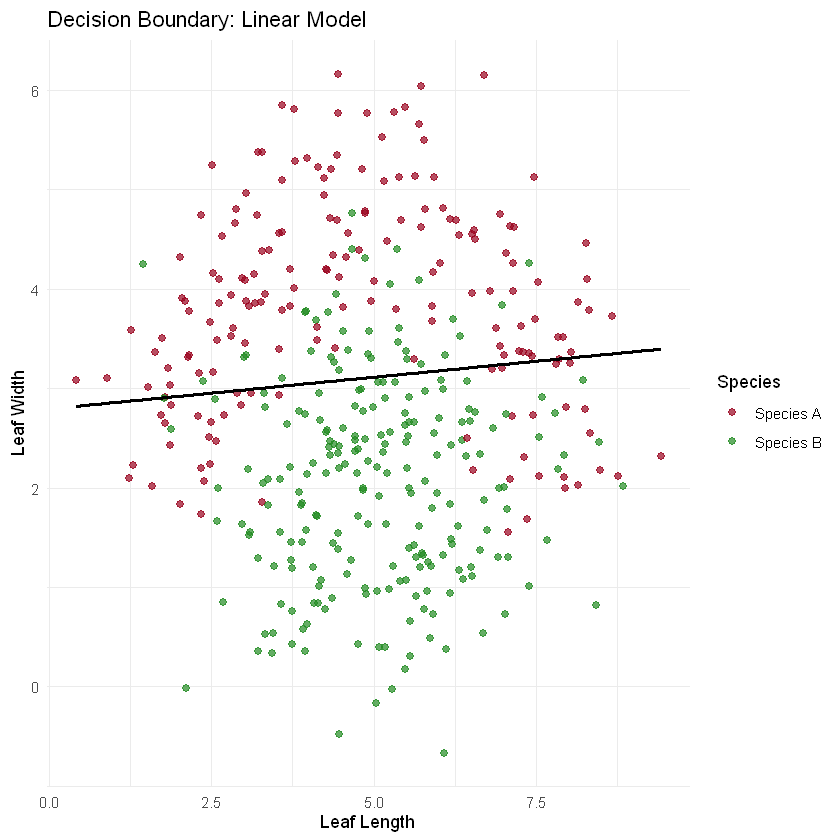

In [258]:
# Linear Model
plot_boundary(grid_df$pred_lin, "Decision Boundary: Linear Model")

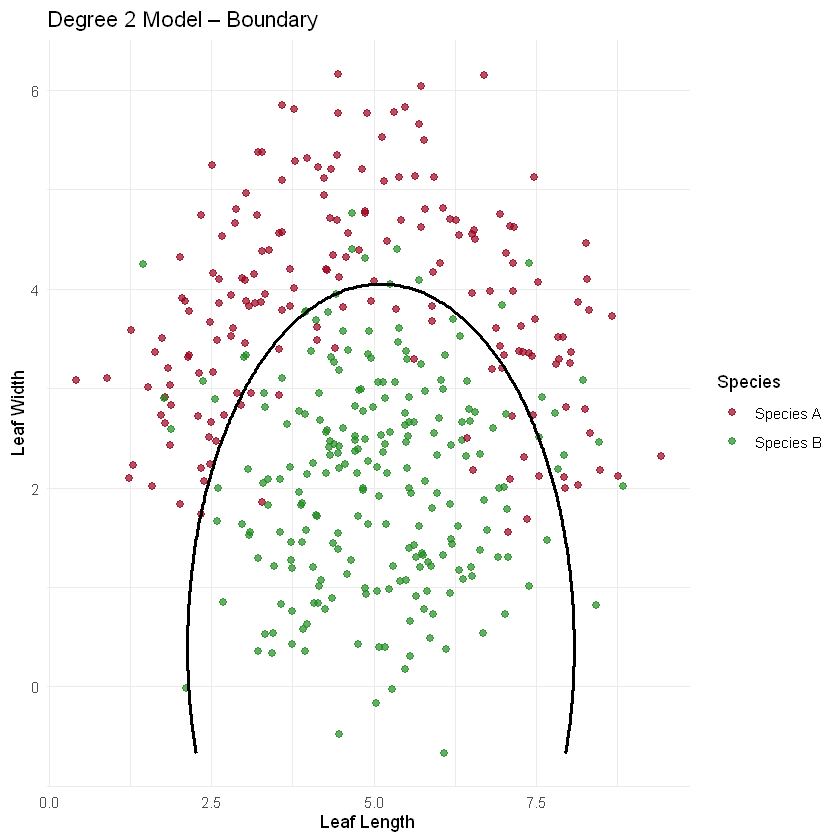

In [259]:
# Polynomial Model - Degree 2
plot_decision(grid_df$pred_d2, "Degree 2 Model – Boundary")

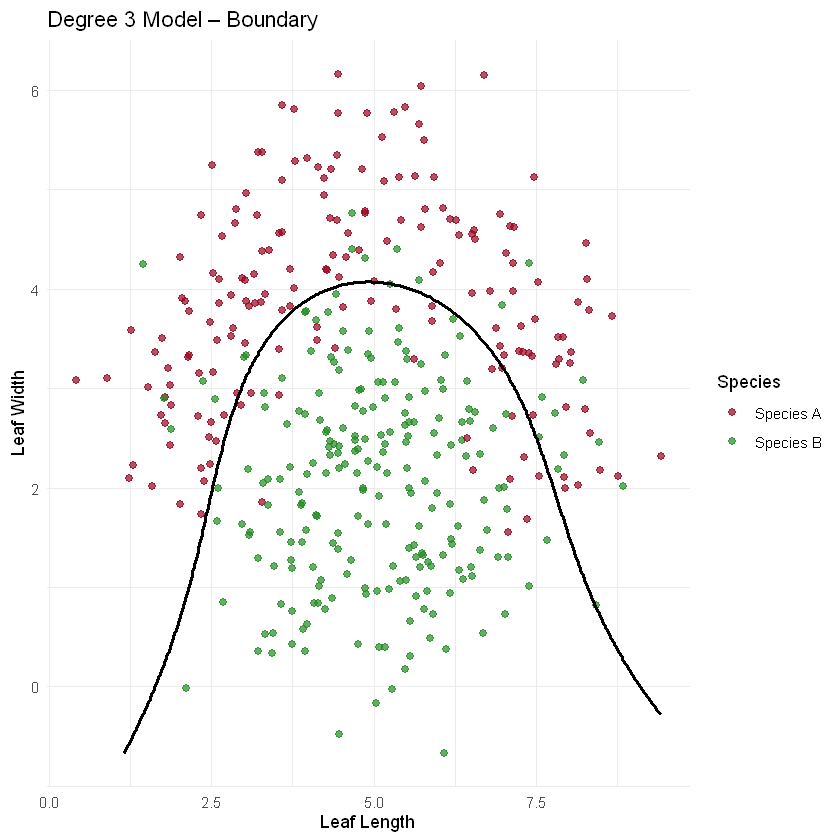

In [260]:
# Polynomial Model - Degree 3
plot_decision(grid_df$pred_d3, "Degree 3 Model – Boundary")

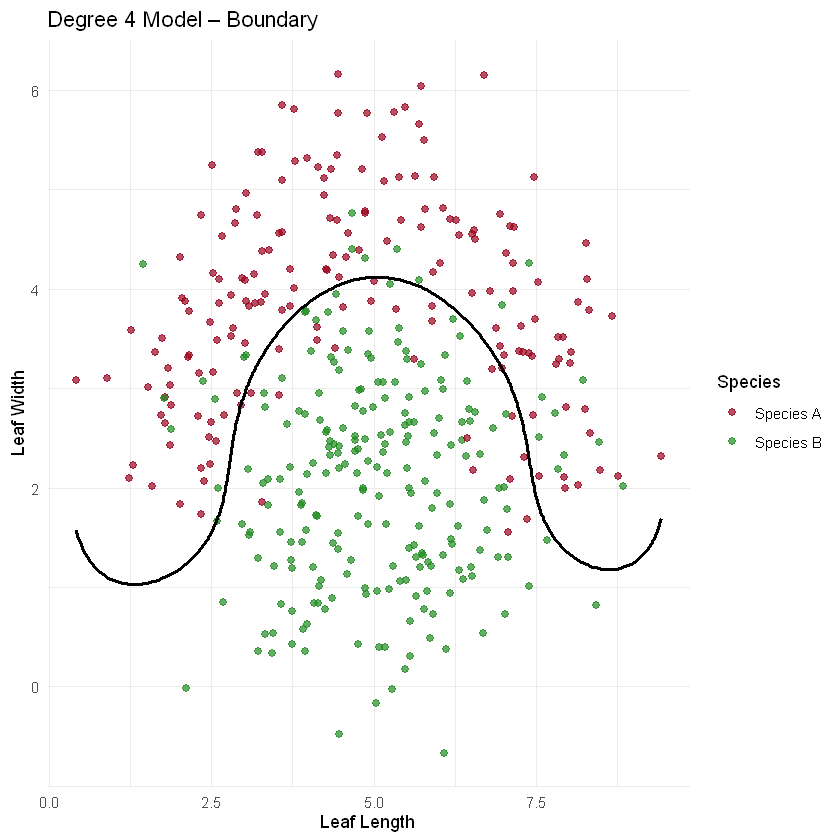

In [261]:
# Polynomial Model - Degree 4
plot_decision(grid_df$pred_d4, "Degree 4 Model – Boundary")

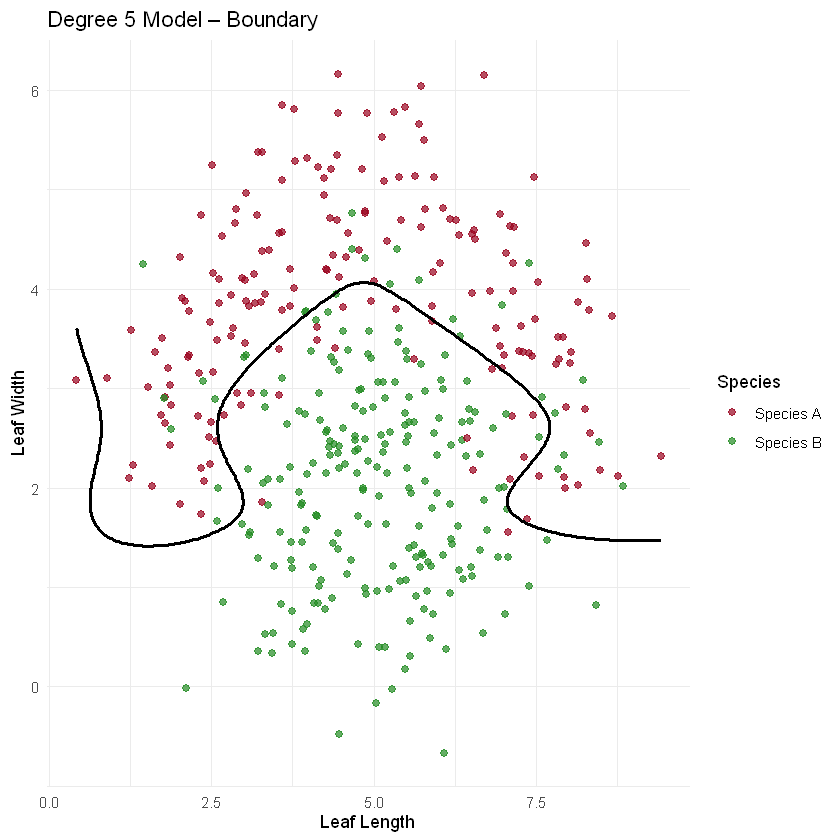

In [262]:
# Polynomial Model - Degree 5
plot_decision(grid_df$pred_d5, "Degree 5 Model – Boundary")

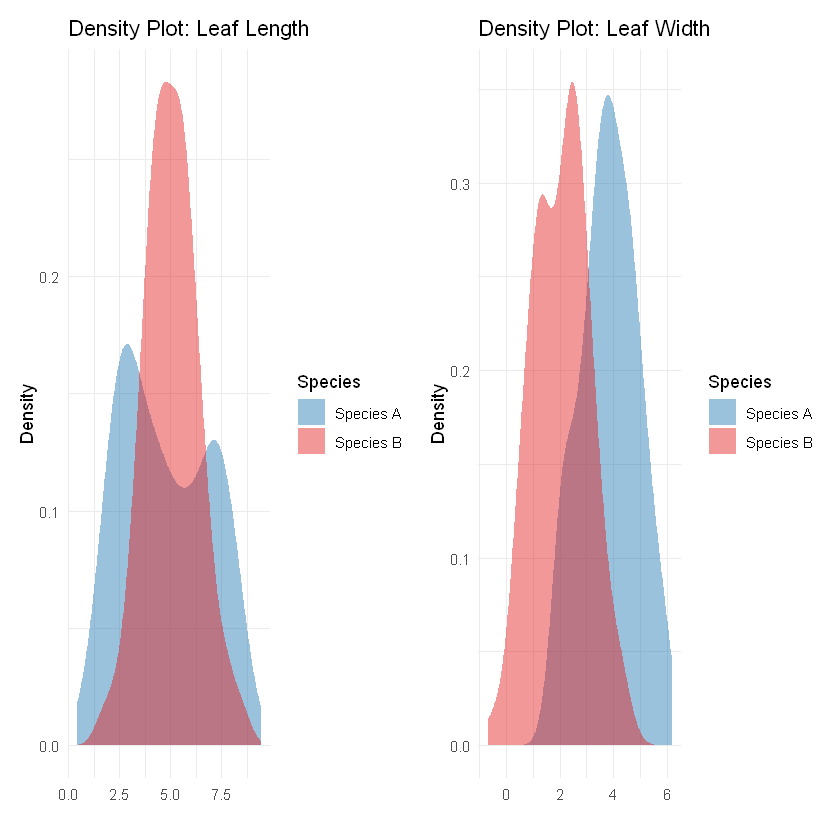

In [248]:
# Density Plots (Leaf Length and Leaf Width)
library(patchwork)

# New, clearly different colours
cols_new <- c("#1f78b4", "#e31a1c")

# Density plot for Leaf Length
p_len <- ggplot(data_6908119, aes(LeafLength, fill = Species)) +
  geom_density(alpha = 0.45, colour = NA) +
  scale_fill_manual(values = cols_new) +
  labs(title = "Density Plot: Leaf Length", y = "Density", x = "") +
  theme_minimal()

# Density plot for Leaf Width
p_wid <- ggplot(data_6908119, aes(LeafWidth, fill = Species)) +
  geom_density(alpha = 0.45, colour = NA) +
  scale_fill_manual(values = cols_new) +
  labs(title = "Density Plot: Leaf Width", y = "Density", x = "") +
  theme_minimal()

# Combine plots
p_len + p_wid

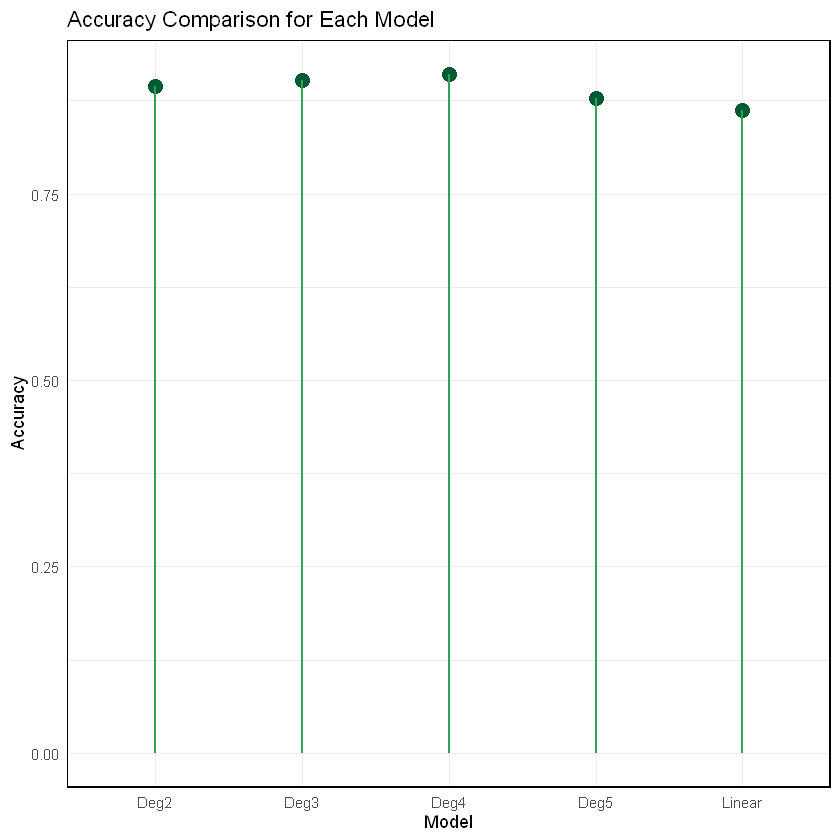

In [249]:
# Lollipop Plot- Accuracy Comparison Across Models
acc_table<-data.frame(
  ModelName=c("Linear", "Deg2", "Deg3", "Deg4", "Deg5"),
  AccValue=c(acc_lin, acc_deg2, acc_deg3, acc_deg4, acc_deg5)
)

ggplot(acc_table, aes(x=ModelName, y=AccValue))+
  geom_point(size=4, colour="#005a32")+
  geom_segment(aes(x=ModelName, xend=ModelName, y=0, yend=AccValue),
              colour="#31a354",linewidth=0.6)+
  labs(title = "Accuracy Comparison for Each Model",
       x = "Model",
       y = "Accuracy")+
  theme_minimal()+
theme(
     panel.border=element_rect(colour="black",fill = NA, linewidth = 0.8),
     panel.background=element_rect(fill="white"),
     plot.background=element_rect(fill="white")
)

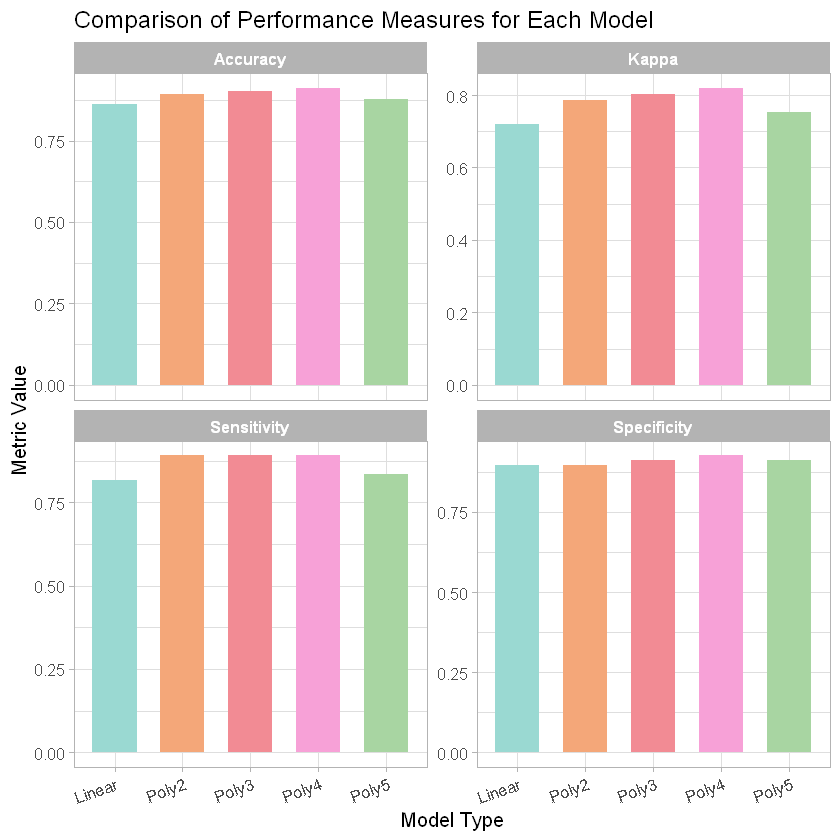

In [250]:
# Custom pastel colours
model_cols <- c(
  "Linear" = "#9AD9D2",
  "Poly2"  = "#F4A779",
  "Poly3"  = "#F28B94",
  "Poly4"  = "#F7A1D7",
  "Poly5"  = "#A8D5A2"
)

# Bar chart using pastel colours
ggplot(data = performance_long) +
  geom_col(aes(Model, Score, fill = Model), width = 0.65) +
  scale_fill_manual(values = model_cols) +
  facet_wrap(vars(Metric), ncol = 2, scales = "free_y") +
  labs(
    title = "Comparison of Performance Measures for Each Model",
    x = "Model Type",
    y = "Metric Value"
  ) +
  theme_light(base_size = 12) +
  theme(
    strip.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 20, hjust = 1),
    legend.position = "none",
    panel.border = element_rect(colour = "grey70", fill = NA)
  )

In [251]:
# ROC- Curve for All Models
library(pROC)
roc_lin<-roc(response=test_chunk$Species,predictor=pred_lin_prob)
roc_d2<-roc(response=test_chunk$Species,predictor=prob_d2)
roc_d3<-roc(response=test_chunk$Species,predictor=prob_d3)
roc_d4<-roc(response=test_chunk$Species,predictor=prob_d4)
roc_d5<-roc(response=test_chunk$Species,predictor=prob_d5)

Setting levels: control = Species A, case = Species B

Setting direction: controls < cases

Setting levels: control = Species A, case = Species B

Setting direction: controls < cases

Setting levels: control = Species A, case = Species B

Setting direction: controls < cases

Setting levels: control = Species A, case = Species B

Setting direction: controls < cases

Setting levels: control = Species A, case = Species B

Setting direction: controls < cases



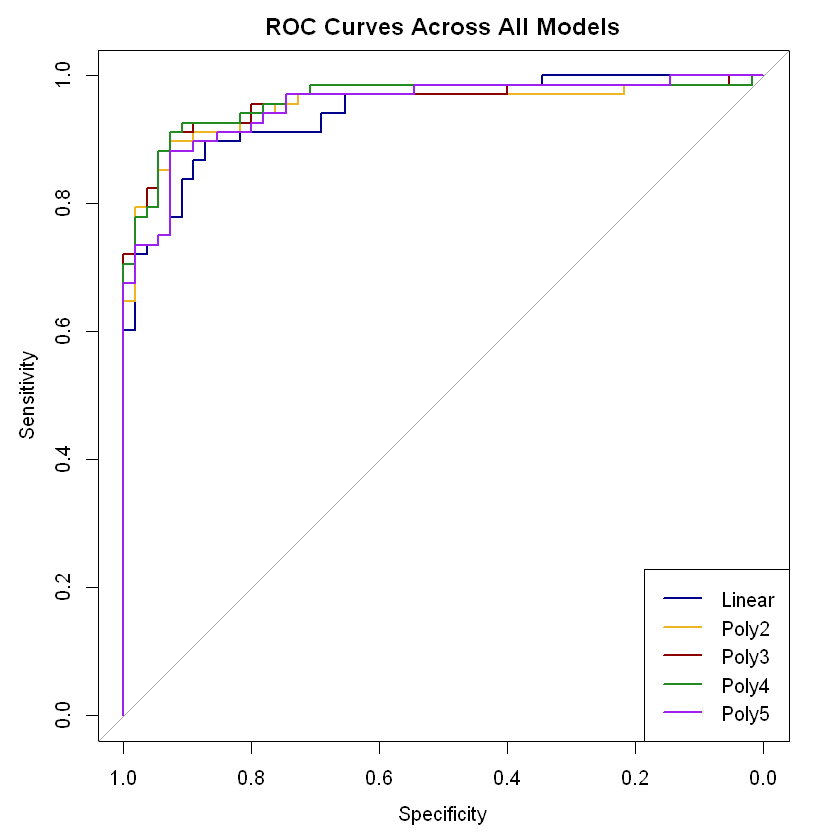

In [252]:
plot(roc_lin,
     col= "darkblue",
     lwd=2.2,
     main="ROC Curves Across All Models")

lines(roc_d2, col= "goldenrod2", lwd=2)
lines(roc_d3, col= "darkred", lwd=2)
lines(roc_d4, col= "forestgreen", lwd=2)
lines(roc_d5, col= "purple", lwd=2)

legend("bottomright",
       legend= c("Linear", "Poly2", "Poly3", "Poly4", "Poly5"),
       
col=c("darkblue", "goldenrod2", "darkred", "forestgreen", "purple"),
       lwd=2)

**Visualisation Notes:** I used a small set of plots to highlight the main aspects of my analysis. The scatter plot at the beginning helped me see how the two species are spread out and whether a straight-line boundary would be effective. I added the density plots to compare the distributions of leaf length and width between the species.

The decision boundary plots show how each separates the two groups and how the boundary becomes more curved as the model grows in complexity. To compare the model performances, I included a lollipop chart for accuracy and a bar chart for the other metrics. These visuals make it easy to see which model improved and where. The ROC curves illustrate how well each model separates the species at different thresholds.

Overall, I chose these plots because each one emphasizes a different part of the results. Together, they provide a clear picture of how the models fit the data and how they differ from each other.